In [ ]:
!wget https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv

#https://github.com/vijendra-code/Time-Series-Forecasting/blob/master/Time%20Series%20Shampoo%20Sales%20Forecast.ipynb

--2025-05-04 22:03:40--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv
Loaded CA certificate '/usr/ssl/certs/ca-bundle.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519 [text/plain]
Saving to: 'shampoo.csv'

     0K                                                       100% 10.8M=0s

2025-05-04 22:03:42 (10.8 MB/s) - 'shampoo.csv' saved [519/519]



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load time series data
dataframe = pd.read_csv("shampoo.csv")
dataframe.head()

,Month,Sales
0,1-01,266.0
1,1-02,145.9
2,1-03,183.1
3,1-04,119.3
4,1-05,180.3


In [2]:
date = pd.date_range(start='1/1/2001', end='12/31/2003', freq='M')
date

C:\Users\ramir\AppData\Local\Temp\ipykernel_74316\4051903570.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date = pd.date_range(start='1/1/2001', end='12/31/2003', freq='M')


DatetimeIndex(['2001-01-31', '2001-02-28', '2001-03-31', '2001-04-30',
               '2001-05-31', '2001-06-30', '2001-07-31', '2001-08-31',
               '2001-09-30', '2001-10-31', '2001-11-30', '2001-12-31',
               '2002-01-31', '2002-02-28', '2002-03-31', '2002-04-30',
               '2002-05-31', '2002-06-30', '2002-07-31', '2002-08-31',
               '2002-09-30', '2002-10-31', '2002-11-30', '2002-12-31',
               '2003-01-31', '2003-02-28', '2003-03-31', '2003-04-30',
               '2003-05-31', '2003-06-30', '2003-07-31', '2003-08-31',
               '2003-09-30', '2003-10-31', '2003-11-30', '2003-12-31'],
              dtype='datetime64[ns]', freq='ME')

In [3]:
dataframe['Timestamp'] = pd.DataFrame(date, columns=['Date'])
dataframe

,Month,Sales,Timestamp
0,1-01,266.0,2001-01-31
1,1-02,145.9,2001-02-28
2,1-03,183.1,2001-03-31
3,1-04,119.3,2001-04-30
4,1-05,180.3,2001-05-31
5,1-06,168.5,2001-06-30
6,1-07,231.8,2001-07-31
7,1-08,224.5,2001-08-31
8,1-09,192.8,2001-09-30
9,1-10,122.9,2001-10-31


In [4]:
dataframe = dataframe.set_index('Timestamp')
dataframe = dataframe.drop(['Month'], axis = 1)
dataframe

,Sales
Timestamp,
2001-01-31,266.0
2001-02-28,145.9
2001-03-31,183.1
2001-04-30,119.3
2001-05-31,180.3
2001-06-30,168.5
2001-07-31,231.8
2001-08-31,224.5
2001-09-30,192.8


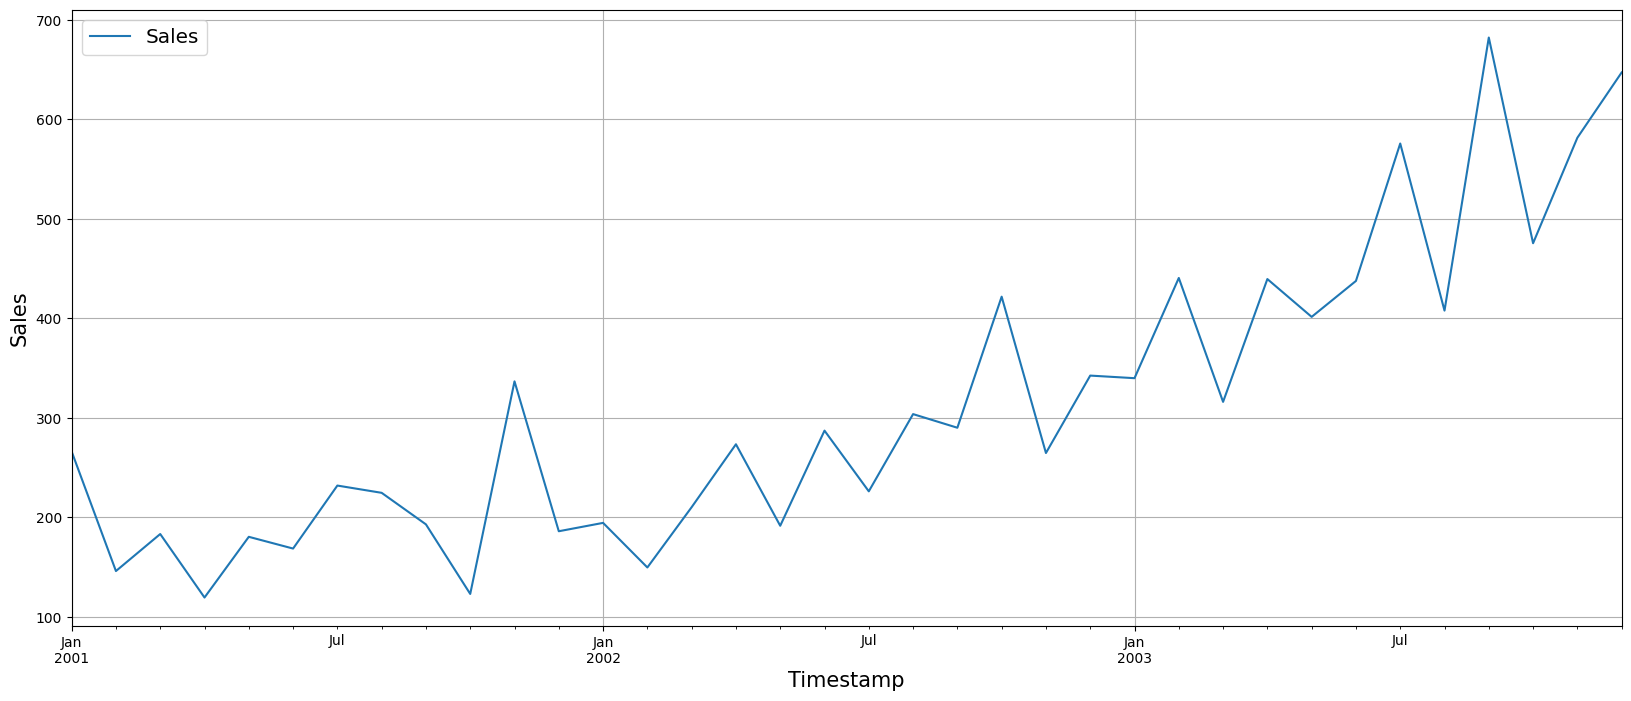

In [6]:
#Plotting the time-series
dataframe.plot(figsize=(20,8))
plt.grid()
plt.xlabel('Timestamp',fontsize=15)
plt.ylabel('Sales',fontsize=15)
plt.rc('xtick',labelsize=15)
plt.rc('ytick',labelsize=15)
plt.legend(fontsize="x-large")

In [5]:
# Define SARIMA model with seasonal components
model = SARIMAX(data, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit()

ValueError: SARIMAX models require univariate `endog`. Got shape (36, 2).

In [6]:
# Forecast future values
forecast = model_fit.forecast(steps=10)

NameError: name 'model_fit' is not defined

TypeError: unhashable type: 'numpy.ndarray'

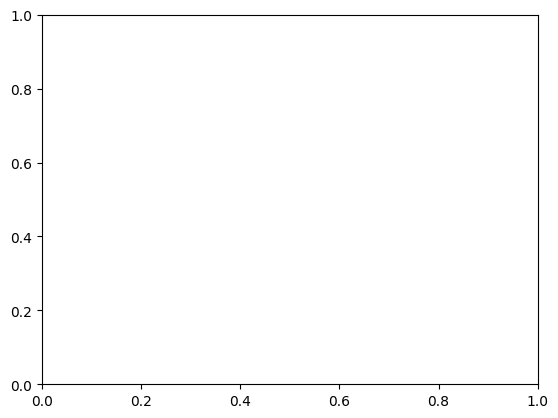

In [7]:
plt.plot(data, label='Original Data')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()